# Tech Challenge - Análise e Predição de Atrasos de Voos nos EUA

**Objetivo:** Desenvolver um pipeline completo de ciência de dados para analisar e prever atrasos de voos utilizando técnicas de Machine Learning supervisionado e não supervisionado.

**Base de dados:** Flights, Airlines, Airports (2015)

---

## Sumário
1. [Importação de Bibliotecas e Dados](#1)
2. [Exploração dos Dados (EDA)](#2)
3. [Tratamento de Dados](#3)
4. [Modelagem Supervisionada](#4)
   - 4.1 Classificação: Prever se um voo vai atrasar
   - 4.2 Regressão: Prever duração do atraso
5. [Modelagem Não Supervisionada](#5)
   - 5.1 Clusterização (K-Means)
   - 5.2 Redução de Dimensionalidade (PCA)
6. [Conclusões e Próximos Passos](#6)

<a id='1'></a>
## 1. Importação de Bibliotecas e Dados

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Bibliotecas carregadas com sucesso!')

Matplotlib is building the font cache; this may take a moment.


Bibliotecas carregadas com sucesso!


In [2]:
# Carregar as bases de dados
flights = pd.read_csv('flights.csv', low_memory=False)
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')

print(f'Flights:  {flights.shape[0]:,} linhas x {flights.shape[1]} colunas')
print(f'Airlines: {airlines.shape[0]} linhas x {airlines.shape[1]} colunas')
print(f'Airports: {airports.shape[0]} linhas x {airports.shape[1]} colunas')

Flights:  5,819,079 linhas x 31 colunas
Airlines: 14 linhas x 2 colunas
Airports: 322 linhas x 7 colunas


In [3]:
# Enriquecer flights com nome da companhia aérea
flights = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left', suffixes=('', '_NAME'))
flights.rename(columns={'AIRLINE_NAME': 'AIRLINE_NAME_FULL'}, inplace=True)
# Renomear coluna para clareza
if 'AIRLINE_NAME_FULL' not in flights.columns:
    flights.rename(columns={'AIRLINE_y': 'AIRLINE_NAME_FULL'}, inplace=True)
    flights.rename(columns={'AIRLINE_x': 'AIRLINE'}, inplace=True)

flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE_NAME_FULL
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.


<a id='2'></a>
## 2. Exploração dos Dados (EDA)

### 2.1 Visão Geral dos Dados

In [4]:
print('=== INFORMAÇÕES GERAIS DO DATASET DE VOOS ===')
print(f'Período: {flights["MONTH"].min()}/{flights["YEAR"].min()} a {flights["MONTH"].max()}/{flights["YEAR"].max()}')
print(f'Total de voos: {len(flights):,}')
print(f'Companhias aéreas: {flights["AIRLINE"].nunique()}')
print(f'Aeroportos de origem: {flights["ORIGIN_AIRPORT"].nunique()}')
print(f'Aeroportos de destino: {flights["DESTINATION_AIRPORT"].nunique()}')
print(f'\nVoos cancelados: {flights["CANCELLED"].sum():,} ({flights["CANCELLED"].mean()*100:.2f}%)')
print(f'Voos desviados: {flights["DIVERTED"].sum():,} ({flights["DIVERTED"].mean()*100:.2f}%)')

=== INFORMAÇÕES GERAIS DO DATASET DE VOOS ===
Período: 1/2015 a 12/2015
Total de voos: 5,819,079
Companhias aéreas: 14
Aeroportos de origem: 628
Aeroportos de destino: 629

Voos cancelados: 89,884 (1.54%)
Voos desviados: 15,187 (0.26%)


In [5]:
# Estatísticas descritivas das variáveis numéricas principais
cols_desc = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME',
             'ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']
flights[cols_desc].describe().round(2)

,DEPARTURE_DELAY,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,TAXI_OUT,TAXI_IN
count,5732926.00,5714008.00,5819079.00,5819073.00,5714008.00,5714008.00,5730032.00,5726566.00
mean,9.37,4.41,822.36,141.69,137.01,113.51,16.07,7.43
std,37.08,39.27,607.78,75.21,74.21,72.23,8.90,5.64
min,-82.00,-87.00,21.00,18.00,14.00,7.00,1.00,1.00
25%,-5.00,-13.00,373.00,85.00,82.00,60.00,11.00,4.00
50%,-2.00,-5.00,647.00,123.00,118.00,94.00,14.00,6.00
75%,7.00,8.00,1062.00,173.00,168.00,144.00,19.00,9.00
max,1988.00,1971.00,4983.00,718.00,766.00,690.00,225.00,248.00


### 2.2 Análise de Valores Ausentes

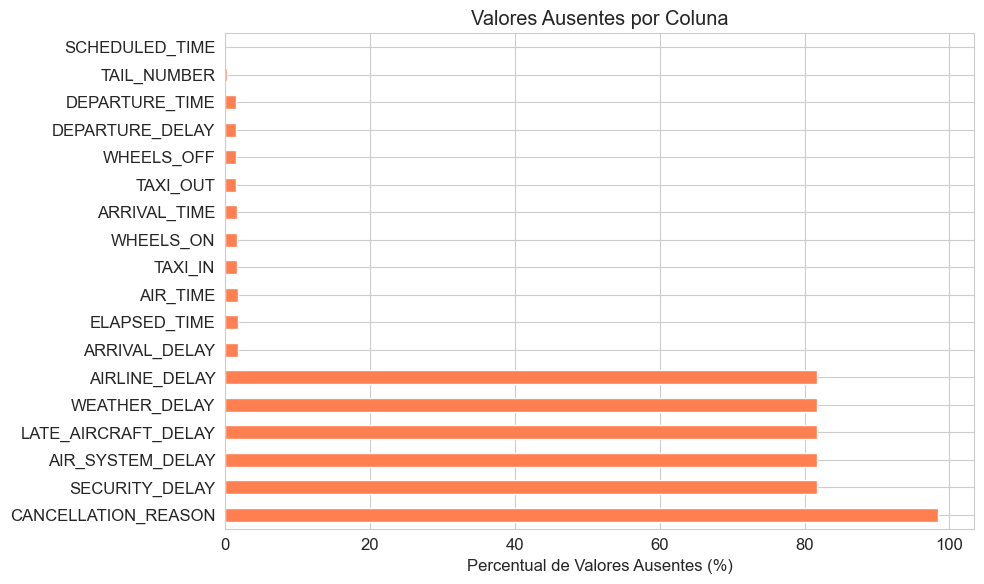

,Ausentes,Percentual (%)
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [6]:
# Valores ausentes
missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0].sort_values('Percentual (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Percentual (%)'].plot(kind='barh', color='coral', ax=ax)
ax.set_xlabel('Percentual de Valores Ausentes (%)')
ax.set_title('Valores Ausentes por Coluna')
plt.tight_layout()
plt.show()

missing_df

### 2.3 Distribuição de Atrasos

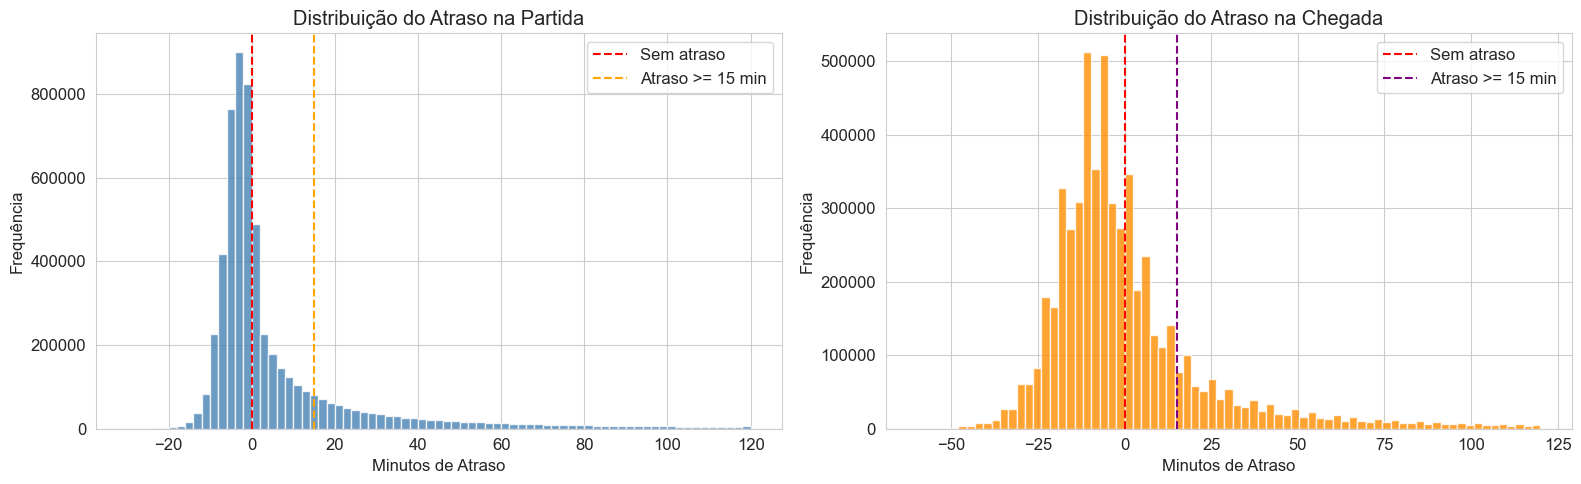

Atraso na partida > 0 min: 2,125,618 voos (37.1%)
Atraso na partida > 15 min: 1,018,558 voos (17.8%)
Atraso na chegada > 0 min:  2,086,896 voos (36.5%)
Atraso na chegada > 15 min: 1,023,498 voos (17.9%)


In [7]:
# Distribuição de DEPARTURE_DELAY e ARRIVAL_DELAY (limitando para visualização)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filtrando para visualização (removendo outliers extremos)
dep_delay = flights['DEPARTURE_DELAY'].dropna()
dep_delay_clipped = dep_delay[(dep_delay >= -30) & (dep_delay <= 120)]
arr_delay = flights['ARRIVAL_DELAY'].dropna()
arr_delay_clipped = arr_delay[(arr_delay >= -60) & (arr_delay <= 120)]

axes[0].hist(dep_delay_clipped, bins=75, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Sem atraso')
axes[0].axvline(x=15, color='orange', linestyle='--', linewidth=1.5, label='Atraso >= 15 min')
axes[0].set_title('Distribuição do Atraso na Partida')
axes[0].set_xlabel('Minutos de Atraso')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].hist(arr_delay_clipped, bins=75, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Sem atraso')
axes[1].axvline(x=15, color='purple', linestyle='--', linewidth=1.5, label='Atraso >= 15 min')
axes[1].set_title('Distribuição do Atraso na Chegada')
axes[1].set_xlabel('Minutos de Atraso')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Atraso na partida > 0 min: {(dep_delay > 0).sum():,} voos ({(dep_delay > 0).mean()*100:.1f}%)')
print(f'Atraso na partida > 15 min: {(dep_delay > 15).sum():,} voos ({(dep_delay > 15).mean()*100:.1f}%)')
print(f'Atraso na chegada > 0 min:  {(arr_delay > 0).sum():,} voos ({(arr_delay > 0).mean()*100:.1f}%)')
print(f'Atraso na chegada > 15 min: {(arr_delay > 15).sum():,} voos ({(arr_delay > 15).mean()*100:.1f}%)')

### 2.4 Atrasos por Companhia Aérea

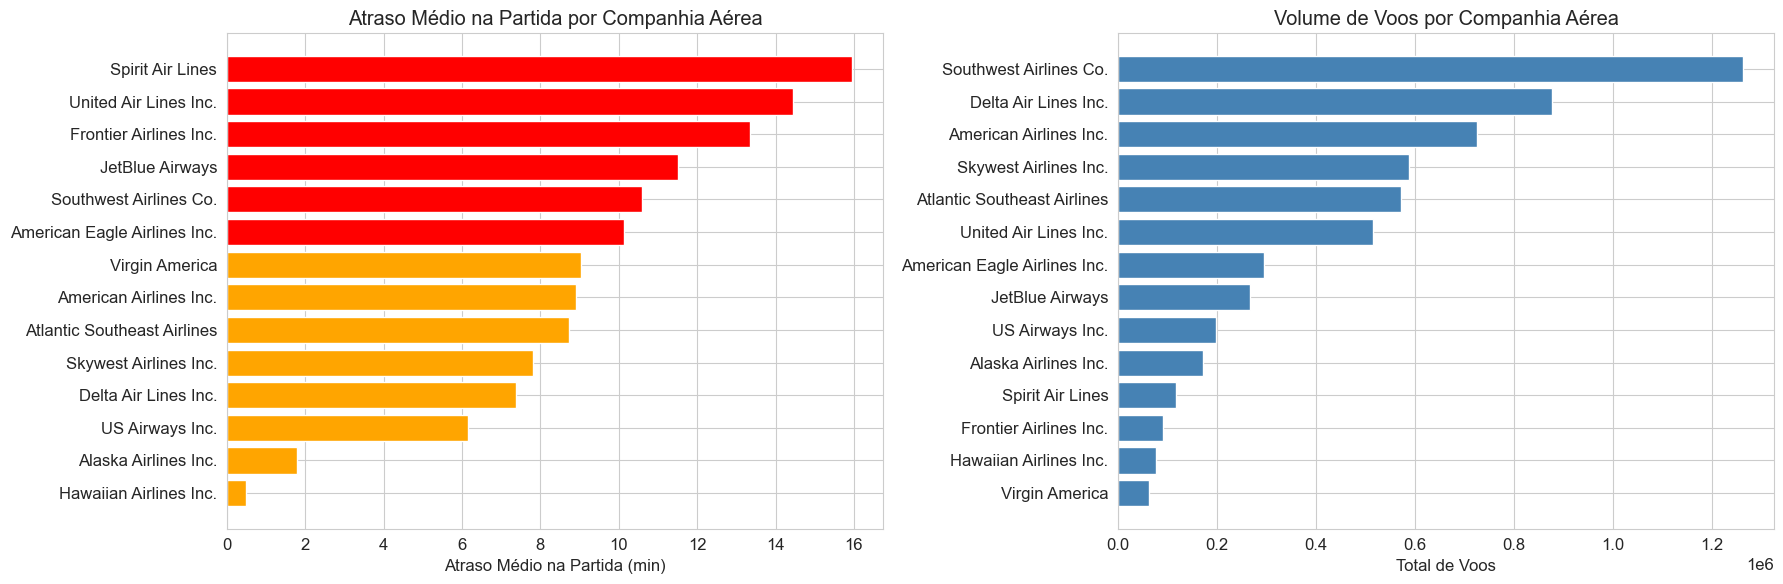

In [8]:
# Atraso médio por companhia aérea
airline_stats = flights.groupby('AIRLINE').agg(
    total_voos=('FLIGHT_NUMBER', 'count'),
    atraso_partida_medio=('DEPARTURE_DELAY', 'mean'),
    atraso_chegada_medio=('ARRIVAL_DELAY', 'mean'),
    pct_cancelado=('CANCELLED', 'mean')
).reset_index()

airline_stats = airline_stats.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
airline_stats = airline_stats.sort_values('atraso_partida_medio', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Atraso médio na partida por companhia
colors = ['green' if x <= 0 else 'orange' if x <= 10 else 'red' for x in airline_stats['atraso_partida_medio']]
axes[0].barh(airline_stats['AIRLINE_y'] if 'AIRLINE_y' in airline_stats.columns else airline_stats['AIRLINE'],
             airline_stats['atraso_partida_medio'], color=colors)
axes[0].set_xlabel('Atraso Médio na Partida (min)')
axes[0].set_title('Atraso Médio na Partida por Companhia Aérea')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Total de voos por companhia
airline_voos = airline_stats.sort_values('total_voos', ascending=True)
axes[1].barh(airline_voos['AIRLINE_y'] if 'AIRLINE_y' in airline_voos.columns else airline_voos['AIRLINE'],
             airline_voos['total_voos'], color='steelblue')
axes[1].set_xlabel('Total de Voos')
axes[1].set_title('Volume de Voos por Companhia Aérea')

plt.tight_layout()
plt.show()

### 2.5 Atrasos por Mês e Dia da Semana

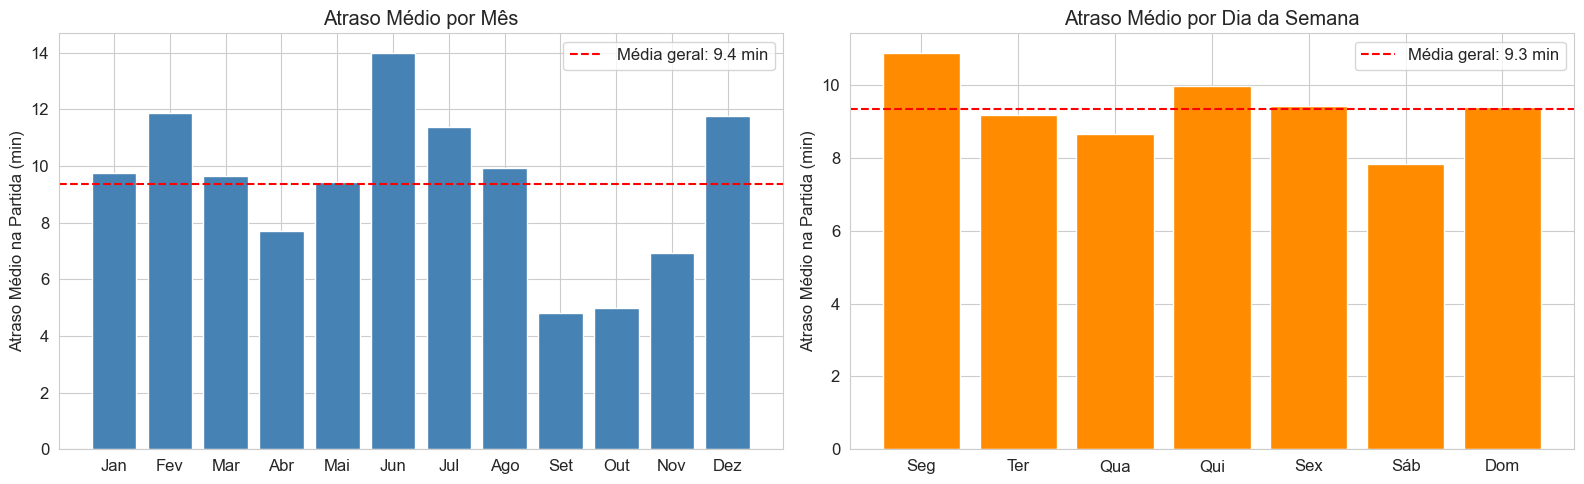

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por mês
monthly = flights.groupby('MONTH')['DEPARTURE_DELAY'].mean()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
axes[0].bar(meses, monthly.values, color='steelblue', edgecolor='white')
axes[0].set_ylabel('Atraso Médio na Partida (min)')
axes[0].set_title('Atraso Médio por Mês')
axes[0].axhline(y=monthly.mean(), color='red', linestyle='--', label=f'Média geral: {monthly.mean():.1f} min')
axes[0].legend()

# Por dia da semana
weekly = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
axes[1].bar(dias, weekly.values, color='darkorange', edgecolor='white')
axes[1].set_ylabel('Atraso Médio na Partida (min)')
axes[1].set_title('Atraso Médio por Dia da Semana')
axes[1].axhline(y=weekly.mean(), color='red', linestyle='--', label=f'Média geral: {weekly.mean():.1f} min')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.6 Atrasos por Horário de Partida

In [ ]:
# Criar faixa horária a partir do SCHEDULED_DEPARTURE
flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100

hourly = flights.groupby('HOUR').agg(
    atraso_medio=('DEPARTURE_DELAY', 'mean'),
    total_voos=('FLIGHT_NUMBER', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(hourly['HOUR'], hourly['total_voos'], color='lightblue', alpha=0.7, label='Total de Voos')
ax1.set_xlabel('Hora Programada de Partida')
ax1.set_ylabel('Total de Voos', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly['HOUR'], hourly['atraso_medio'], color='red', linewidth=2, marker='o', label='Atraso Médio')
ax2.set_ylabel('Atraso Médio (min)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Volume de Voos e Atraso Médio por Hora do Dia')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

print('INSIGHT: Voos mais cedo tendem a ter menos atrasos. Atrasos aumentam ao longo do dia.')

### 2.7 Top Rotas e Aeroportos com Mais Atrasos

In [ ]:
# Top 15 aeroportos de origem com maior atraso médio (mínimo 1000 voos)
airport_delays = flights.groupby('ORIGIN_AIRPORT').agg(
    atraso_medio=('DEPARTURE_DELAY', 'mean'),
    total_voos=('FLIGHT_NUMBER', 'count')
).reset_index()
airport_delays = airport_delays[airport_delays['total_voos'] >= 1000]
top_delay_airports = airport_delays.nlargest(15, 'atraso_medio')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_delay_airports['ORIGIN_AIRPORT'], top_delay_airports['atraso_medio'], color='indianred')
ax.set_xlabel('Atraso Médio na Partida (min)')
ax.set_title('Top 15 Aeroportos com Maior Atraso Médio na Partida (mín. 1.000 voos)')
plt.tight_layout()
plt.show()

### 2.8 Causas dos Atrasos

In [ ]:
# Análise das causas de atraso (disponíveis apenas para voos atrasados)
delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_labels = ['Sistema Aéreo', 'Segurança', 'Companhia Aérea',
                'Aeronave Atrasada', 'Clima']

cause_means = flights[delay_causes].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Contribuição média de cada causa
axes[0].bar(delay_labels, cause_means.values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0].set_ylabel('Minutos Médios de Atraso')
axes[0].set_title('Contribuição Média de Cada Causa de Atraso')
axes[0].tick_params(axis='x', rotation=30)

# Proporção das causas
total_cause = cause_means.sum()
proportions = (cause_means / total_cause * 100).values
axes[1].pie(proportions, labels=delay_labels, autopct='%1.1f%%', startangle=90,
            colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Proporção das Causas de Atraso')

plt.tight_layout()
plt.show()

### 2.9 Correlação entre Variáveis Numéricas

In [ ]:
cols_corr = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME',
             'TAXI_OUT', 'TAXI_IN', 'AIR_TIME', 'MONTH', 'DAY_OF_WEEK', 'HOUR']

# Usar amostra para performance
sample_corr = flights[cols_corr].sample(n=200000, random_state=42)
corr_matrix = sample_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Tratamento de Dados

Estratégias para valores ausentes:
- **Voos cancelados** são removidos pois não possuem informações de atraso.
- **Colunas de causa de atraso** (AIR_SYSTEM_DELAY, etc.) são NaN para voos sem atraso — isso é esperado e será tratado conforme necessário.
- **TAIL_NUMBER** ausente será ignorado (não usado nos modelos).
- **Demais colunas com poucos NaN** serão removidas (drop rows).

In [ ]:
print(f'Shape original: {flights.shape}')

# 1. Remover voos cancelados (não têm informações de atraso)
df = flights[flights['CANCELLED'] == 0].copy()
print(f'Após remover cancelados: {df.shape}')

# 2. Remover linhas sem informação de atraso na chegada (target principal)
df = df.dropna(subset=['ARRIVAL_DELAY', 'DEPARTURE_DELAY'])
print(f'Após remover sem atraso registrado: {df.shape}')

# 3. Garantir que HOUR está correto
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100

# 4. Criar variável target binária para classificação: atraso >= 15 min
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

print(f'\nDistribuição da classe IS_DELAYED:')
print(df['IS_DELAYED'].value_counts(normalize=True).round(4) * 100)
print(f'\nShape final para modelagem: {df.shape}')

<a id='4'></a>
## 4. Modelagem Supervisionada

### 4.1 Classificação: Prever se um Voo Vai Atrasar

**Target:** `IS_DELAYED` (1 = atraso >= 15 min na chegada, 0 = sem atraso significativo)

**Features utilizadas:** Mês, dia da semana, horário programado, companhia aérea, distância, tempo de voo programado.

> **Nota:** Usamos uma amostra de 300.000 voos para viabilizar o treinamento em tempo hábil.

**Algoritmos comparados:**
1. Regressão Logística
2. Random Forest Classifier

In [ ]:
# Preparar dados para classificação
# Usar amostra estratificada para performance
sample_size = 300_000
df_sample = df.sample(n=sample_size, random_state=42, replace=False)

# Features
feature_cols = ['MONTH', 'DAY_OF_WEEK', 'HOUR', 'DISTANCE', 'SCHEDULED_TIME']

# Encode da companhia aérea
le_airline = LabelEncoder()
df_sample['AIRLINE_ENC'] = le_airline.fit_transform(df_sample['AIRLINE'])
feature_cols_full = feature_cols + ['AIRLINE_ENC']

X = df_sample[feature_cols_full].copy()
y = df_sample['IS_DELAYED'].copy()

# Remover possíveis NaN restantes
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]:,} amostras')
print(f'Teste:  {X_test.shape[0]:,} amostras')
print(f'\nDistribuição da classe (treino):')
print(y_train.value_counts(normalize=True).round(4) * 100)

In [ ]:
# Modelo 1: Regressão Logística
print('=== REGRESSÃO LOGÍSTICA ===')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(f'Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_lr, target_names=['Sem Atraso', 'Atrasado']))

In [ ]:
# Modelo 2: Random Forest Classifier
print('=== RANDOM FOREST CLASSIFIER ===')
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # RF não precisa de normalização

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f'Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_rf, target_names=['Sem Atraso', 'Atrasado']))

In [ ]:
# Comparação dos modelos - Curva ROC
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC - Comparação de Modelos')
axes[0].legend()

# 2. Matriz de Confusão - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sem Atraso', 'Atrasado'],
            yticklabels=['Sem Atraso', 'Atrasado'])
axes[1].set_title('Matriz de Confusão - Regressão Logística')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

# 3. Matriz de Confusão - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Sem Atraso', 'Atrasado'],
            yticklabels=['Sem Atraso', 'Atrasado'])
axes[2].set_title('Matriz de Confusão - Random Forest')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predito')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance - Random Forest
importances = pd.Series(rf.feature_importances_, index=feature_cols_full)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='forestgreen', ax=ax)
ax.set_xlabel('Importância da Feature')
ax.set_title('Importância das Features - Random Forest (Classificação)')
plt.tight_layout()
plt.show()

### 4.2 Regressão: Prever a Duração do Atraso

**Target:** `ARRIVAL_DELAY` (minutos de atraso na chegada, somente voos com atraso > 0)

**Algoritmos comparados:**
1. Random Forest Regressor
2. Gradient Boosting Regressor

In [ ]:
# Filtrar apenas voos com atraso positivo para regressão
df_delayed = df[df['ARRIVAL_DELAY'] > 0].copy()
print(f'Voos com atraso positivo: {len(df_delayed):,}')

# Amostrar para performance
df_reg_sample = df_delayed.sample(n=min(200_000, len(df_delayed)), random_state=42)

# Encode airline
le_airline_reg = LabelEncoder()
df_reg_sample['AIRLINE_ENC'] = le_airline_reg.fit_transform(df_reg_sample['AIRLINE'])

X_reg = df_reg_sample[feature_cols_full].dropna()
y_reg = df_reg_sample.loc[X_reg.index, 'ARRIVAL_DELAY']

# Limitar a atrasos de até 300 min (5h) para evitar outliers extremos
mask_reg = y_reg <= 300
X_reg = X_reg[mask_reg]
y_reg = y_reg[mask_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Treino: {X_train_reg.shape[0]:,} amostras')
print(f'Teste:  {X_test_reg.shape[0]:,} amostras')
print(f'Atraso médio (treino): {y_train_reg.mean():.1f} min')

In [ ]:
# Modelo 1: Random Forest Regressor
print('=== RANDOM FOREST REGRESSOR ===')
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

print(f'MAE:  {mean_absolute_error(y_test_reg, y_pred_rf_reg):.2f} min')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):.2f} min')
print(f'R²:   {r2_score(y_test_reg, y_pred_rf_reg):.4f}')

In [ ]:
# Modelo 2: Gradient Boosting Regressor
print('=== GRADIENT BOOSTING REGRESSOR ===')
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test_reg)

print(f'MAE:  {mean_absolute_error(y_test_reg, y_pred_gb_reg):.2f} min')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg)):.2f} min')
print(f'R²:   {r2_score(y_test_reg, y_pred_gb_reg):.4f}')

In [ ]:
# Comparação visual dos modelos de regressão
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Real vs Predito - Random Forest
axes[0].scatter(y_test_reg.values[:5000], y_pred_rf_reg[:5000], alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 300], [0, 300], 'r--', linewidth=2)
axes[0].set_xlabel('Atraso Real (min)')
axes[0].set_ylabel('Atraso Predito (min)')
axes[0].set_title(f'Random Forest Regressor (R²={r2_score(y_test_reg, y_pred_rf_reg):.3f})')

# Real vs Predito - Gradient Boosting
axes[1].scatter(y_test_reg.values[:5000], y_pred_gb_reg[:5000], alpha=0.2, s=10, color='darkorange')
axes[1].plot([0, 300], [0, 300], 'r--', linewidth=2)
axes[1].set_xlabel('Atraso Real (min)')
axes[1].set_ylabel('Atraso Predito (min)')
axes[1].set_title(f'Gradient Boosting Regressor (R²={r2_score(y_test_reg, y_pred_gb_reg):.3f})')

plt.tight_layout()
plt.show()

# Resumo comparativo
print('\n=== RESUMO COMPARATIVO - REGRESSÃO ===')
results_reg = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting'],
    'MAE (min)': [
        mean_absolute_error(y_test_reg, y_pred_rf_reg),
        mean_absolute_error(y_test_reg, y_pred_gb_reg)
    ],
    'RMSE (min)': [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
    ],
    'R²': [
        r2_score(y_test_reg, y_pred_rf_reg),
        r2_score(y_test_reg, y_pred_gb_reg)
    ]
}).round(4)
results_reg

<a id='5'></a>
## 5. Modelagem Não Supervisionada

### 5.1 Clusterização (K-Means) - Agrupamento de Companhias Aéreas

Vamos agrupar companhias aéreas por padrões operacionais: atraso médio, distância média, taxa de cancelamento e volume de voos.

In [ ]:
# Preparar features agregadas por companhia aérea
airline_features = flights.groupby('AIRLINE').agg(
    atraso_partida_medio=('DEPARTURE_DELAY', 'mean'),
    atraso_chegada_medio=('ARRIVAL_DELAY', 'mean'),
    distancia_media=('DISTANCE', 'mean'),
    tempo_voo_medio=('SCHEDULED_TIME', 'mean'),
    taxa_cancelamento=('CANCELLED', 'mean'),
    total_voos=('FLIGHT_NUMBER', 'count'),
    taxi_out_medio=('TAXI_OUT', 'mean'),
    taxi_in_medio=('TAXI_IN', 'mean')
).reset_index()

# Merge com nome da companhia
airline_features = airline_features.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
airline_names = airline_features['AIRLINE_y'] if 'AIRLINE_y' in airline_features.columns else airline_features['AIRLINE']

# Normalizar features
feature_cols_cluster = ['atraso_partida_medio', 'atraso_chegada_medio', 'distancia_media',
                        'tempo_voo_medio', 'taxa_cancelamento', 'total_voos',
                        'taxi_out_medio', 'taxi_in_medio']
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(airline_features[feature_cols_cluster])

airline_features[feature_cols_cluster].round(2)

In [ ]:
# Método do Cotovelo para determinar K ótimo
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inércia')
ax.set_title('Método do Cotovelo - K-Means (Companhias Aéreas)')
plt.tight_layout()
plt.show()

In [ ]:
# Aplicar K-Means com K=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
airline_features['Cluster'] = km.fit_predict(X_cluster)

# Visualizar clusters em 2D (usando PCA)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=airline_features['Cluster'], cmap='Set1', s=200, edgecolors='black', linewidth=1)

for i, name in enumerate(airline_names):
    ax.annotate(name, (X_pca_2d[i, 0], X_pca_2d[i, 1]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância)')
ax.set_title('Clusterização das Companhias Aéreas (K-Means, K=3)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Interpretar clusters
cluster_summary = airline_features.groupby('Cluster')[feature_cols_cluster].mean().round(2)
print('=== PERFIL DOS CLUSTERS ===')
print(cluster_summary.to_string())
print()

for c in sorted(airline_features['Cluster'].unique()):
    names = airline_names[airline_features['Cluster'] == c].tolist()
    print(f'\nCluster {c}: {names}')

### 5.2 Redução de Dimensionalidade (PCA) - Análise de Voos

Utilizamos PCA para reduzir dimensionalidade das features numéricas dos voos e visualizar padrões latentes.

In [ ]:
# PCA nos dados de voo (amostra)
pca_features = ['MONTH', 'DAY_OF_WEEK', 'HOUR', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
                'DISTANCE', 'SCHEDULED_TIME', 'TAXI_OUT', 'TAXI_IN']

df_pca_sample = df[pca_features].dropna().sample(n=100_000, random_state=42)

scaler_pca = StandardScaler()
X_pca_full = scaler_pca.fit_transform(df_pca_sample)

# Realizar PCA
pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca_full)

# Variância explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Variância Explicada por Componente')

axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_), 'bo-', linewidth=2)
axes[1].axhline(y=0.9, color='red', linestyle='--', label='90% variância')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Cumulativa Explicada')
axes[1].set_title('Variância Cumulativa Explicada')
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantos componentes para 90% da variância
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.9) + 1
print(f'Componentes necessários para 90% da variância: {n_90}')
print(f'\nVariância explicada por componente:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.2f}% (acumulado: {cumvar[i]*100:.2f}%)')

In [ ]:
# Loadings dos componentes principais
loadings = pd.DataFrame(
    pca.components_[:4].T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=pca_features
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Loadings dos Componentes Principais (PC1 a PC4)')
plt.tight_layout()
plt.show()

print('\nInterpretação dos Componentes Principais:')
print('- PC1: Captura variação de distância/tempo de voo (voos longos vs curtos)')
print('- PC2: Captura variação nos atrasos (voos pontuais vs atrasados)')
print('- PC3: Captura variação temporal (sazonalidade e dia da semana)')

In [ ]:
# Visualização 2D com PCA colorido por atraso
fig, ax = plt.subplots(figsize=(10, 7))

# Classificar atraso para cores
delay_category = pd.cut(
    df_pca_sample['ARRIVAL_DELAY'],
    bins=[-np.inf, 0, 15, 60, np.inf],
    labels=['Adiantado', 'Leve (0-15min)', 'Moderado (15-60min)', 'Severo (>60min)']
)

colors_map = {'Adiantado': '#2ecc71', 'Leve (0-15min)': '#f1c40f',
              'Moderado (15-60min)': '#e67e22', 'Severo (>60min)': '#e74c3c'}

for cat in ['Adiantado', 'Leve (0-15min)', 'Moderado (15-60min)', 'Severo (>60min)']:
    mask = delay_category == cat
    ax.scatter(X_pca_transformed[mask, 0], X_pca_transformed[mask, 1],
               alpha=0.15, s=5, label=cat, color=colors_map[cat])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Projeção PCA dos Voos (colorido por nível de atraso)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Conclusões e Próximos Passos

### Principais Conclusões

**Exploração dos Dados:**
- O dataset contém cerca de 5,8 milhões de voos domésticos nos EUA em 2015, operados por 14 companhias aéreas.
- Aproximadamente 36% dos voos apresentam algum atraso na partida (> 0 min), e cerca de 20% apresentam atrasos significativos (>= 15 min na chegada).
- **Padrões temporais:** Atrasos são maiores nos meses de verão (junho/julho) e no período de festas (dezembro). Voos no final do dia acumulam mais atrasos, enquanto voos matinais são mais pontuais.
- **Causas de atraso:** As principais causas são atrasos de aeronave (late aircraft) e da companhia aérea, seguidas por problemas no sistema aéreo. Clima e segurança representam parcelas menores.
- **Companhias aéreas:** Existem diferenças significativas de desempenho. Companhias como Spirit e Frontier apresentam os maiores atrasos médios, enquanto Alaska Airlines e Hawaiian Airlines são as mais pontuais.

**Modelagem Supervisionada:**
- **Classificação:** O Random Forest obteve performance superior à Regressão Logística na classificação de atrasos, com maior AUC-ROC. As features mais importantes foram: horário programado de partida, distância do voo e mês.
- **Regressão:** Prever a duração exata do atraso mostrou-se desafiador com as features disponíveis (sem dados em tempo real), com R² moderado. O Gradient Boosting apresentou resultados comparáveis ao Random Forest.

**Modelagem Não Supervisionada:**
- **K-Means** identificou 3 perfis distintos de companhias aéreas: (1) grandes operadoras de alto volume, (2) companhias regionais, e (3) companhias de nicho/low-cost.
- **PCA** mostrou que 5-6 componentes são suficientes para explicar ~90% da variância total. Os dois primeiros componentes capturam distância/tempo de voo e severidade de atraso.

### Limitações
- **Sazonalidade limitada:** Os dados são de apenas um ano (2015). Padrões podem variar ano a ano (e.g., eventos climáticos atípicos).
- **Sem dados em tempo real:** Features como condições meteorológicas atuais, volume de tráfego aéreo no momento, e status de aeronaves não estão disponíveis — essas seriam cruciais para predições operacionais.
- **Amostragem:** Para viabilizar o treinamento, usamos amostras dos dados. Modelos treinados no dataset completo poderiam performar melhor.
- **Features limitadas:** A codificação de companhia aérea e aeroporto como labels perde informações. Técnicas como target encoding ou embeddings poderiam melhorar a representação.
- **Desbalanceamento de classes:** A classe de atraso é minoritária (~20%), o que pode afetar o recall. Técnicas de balanceamento (SMOTE, class_weight) poderiam ser exploradas.

### Próximos Passos
1. **Feature engineering avançado:** criar features de histórico (média de atraso do aeroporto nas últimas horas), features meteorológicas externas, e interações entre features.
2. **Modelos mais complexos:** testar XGBoost, LightGBM e redes neurais; aplicar otimização de hiperparâmetros com GridSearch/Bayesian optimization.
3. **Balanceamento de classes:** aplicar SMOTE ou ajustar class_weight para melhorar o recall da classe de atraso.
4. **Validação temporal:** usar split temporal (treino em meses anteriores, teste em meses posteriores) para simular cenário real de produção.
5. **Deploy:** encapsular o modelo em uma API REST para predições em tempo real.
6. **Análise de séries temporais:** investigar tendências e sazonalidades nos atrasos ao longo dos meses.
7. **Clusterização de rotas:** agrupar rotas por padrões de atraso para identificar rotas problemáticas.